# Model agreement vs LLM judges on long rule sentences (R_COMP-SIG)

This notebook is a runnable walk-through of **round-3 experiment 7**. The experiment asks whether *cross-family model agreement* (consensus) predicts if an NL→FOL translation is faithful, without any gold formula. It compares consensus with LLM-as-judge scores.

**Setup of the original experiment**
- **R_COMP**: 221 templated long rule sentences (≥25 words, ≥3 conditions, one *unless / except / provided that / only if* clause). Because the sentences are generated from templates, the correct formulas are known by construction: a *weak* and a *strong* reading of the exception clause.
- 10 few-shot LLM slots from 9 vendor families translate each sentence. In the **SIG** condition, each model is given the predicate signature.
- **Label**: pure z3 equivalence to the weak or strong reading. A translation equivalent to either reading is CORRECT; otherwise it is ERROR (there are also READING_CHOICE, OFF_SIGNATURE and UNPARSEABLE rows).
- **Metric** `c_score_sig`: the share of *family-disjoint* peers whose translation is **not** z3-equivalent to the candidate. Higher means more likely an error.
- **Primary pre-registered test**: the within-template AUROC of `c_score_sig`, minus that of the disguised `gemini-2.5-flash-lite` rubric judge (`judge_cheap_disg`), with a sentence-clustered, template-stratified bootstrap. Full run: **0.954 vs 0.587, Δ = +0.367 [0.328, 0.404] → PASS**.

**What this demo does**, on a 10-sentence × 10-slot subset (100 candidate rows):
1. It re-implements the metric `consensus_exact` using the artifact's own z3 FOL parser, and recomputes `c_score_sig` from the raw candidate formulas.
2. It runs the artifact's stratified-AUROC and bootstrap code (`auc_tools.py`, `analyse.py:delta_block`) for the primary comparison.
3. It runs `method.py build()`, which packs the rows into the `method_out.json` schema.
4. It plots the results.

LLM generations and judge scores are **not** re-run, because that needs API keys and money. They are loaded from the data file as the experiment stored them.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru — NOT pre-installed on Colab, always install
_pip('z3-solver==5.1.0.0', 'loguru==0.7.3')

# numpy, scikit-learn, matplotlib — pre-installed on Colab, install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scikit-learn==1.6.1', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## Imports
These are the original `method.py` imports, plus those of the artifact modules this notebook inlines (`fol.py`, `consensus_rcomp.py`, `auc_tools.py`, `analyse.py`) and matplotlib for the plots.

In [2]:
from __future__ import annotations

# --- method.py ---
import argparse
import json
import subprocess
import sys
from pathlib import Path

from loguru import logger

# --- rcomp/labeller/fol.py, src/consensus_rcomp.py, src/auc_tools.py, src/analyse.py ---
import hashlib
import re
import signal
import time
from collections import Counter, defaultdict

import numpy as np
import z3

# --- notebook additions (visualisation) ---
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

## Load the demo data
`mini_demo_data.json` holds:
- `sentences`: the 10 sentences, with their weak and strong reference readings;
- `rows`: 100 candidate translations, with the z3 label, the stored consensus scores and the stored judge scores;
- `full_run_primary`: the full-run primary-test numbers, for comparison.

The notebook loads the file from GitHub and falls back to a local copy.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/main/round-3/experiment-7/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(len(data["sentences"]), "sentences,", len(data["rows"]), "candidate rows")
print("labels:", Counter(r["label"] for r in data["rows"]))

10 sentences, 100 candidate rows
labels: Counter({'CORRECT': 62, 'ERROR': 28, 'READING_CHOICE': 5, 'OFF_SIGNATURE': 4, 'UNPARSEABLE': 1})


## Configuration
All tunable parameters are set here. The original values are given in the comments.
- `N_SENTENCES`: how many of the 10 demo sentences to process (the original run used all 221).
- `B`: the number of bootstrap replicates for the AUROC confidence intervals (original `--B 2000`).
- `Z3_MS` and `PAIR_CAP_S`: the per-pair z3 timeout and the wall-clock cap. These are frozen pre-registered parameters: 5000 ms and 30 s.

In [5]:
N_SENTENCES = 10      # demo sentences to score (original: all 221 R_COMP sentences)
B = 2000              # bootstrap replicates (original: 2000)
Z3_MS = 5000          # z3 timeout per equivalence check, ms (original, frozen: 5000)
PAIR_CAP_S = 30       # wall-clock cap per pair, s (original, frozen: 30)
SEED = 20260924       # bootstrap seed (original analyse.py SEED)

## FOL parser and z3 equivalence (`rcomp/labeller/fol.py`)
This is the artifact's Unicode-FOL parser (FOLIO/MALLS notation) and its z3 translation, copied as is. Only the parts consensus needs are included: `tokenize`, `Parser`, `parse`, `preds`, `to_z3`, `mkpred`, `valid` and `equivalent`. Two formulas are **equivalent** if `F1 ↔ F2` is valid, which is checked by asking z3 whether its negation is unsatisfiable. If z3 hits the timeout, the result is `None` (unknown).

In [6]:
TOK = re.compile(r"\s*(∀|∃|¬|∧|∨|→|↔|⊕|\(|\)|,|[A-Za-z_][A-Za-z0-9_'\-]*)")
OPS = {"↔": "iff", "⊕": "xor", "→": "imp", "∨": "or", "∧": "and"}
IDENT = re.compile(r"^[A-Za-z_][A-Za-z0-9_'\-]*$")
PREC = {"iff": 1, "imp": 2, "xor": 3, "or": 3, "and": 4}  # FIX (gen_art_dataset_1): ⊕ moved to the ∨ level, binds tighter than →


def tokenize(s: str) -> list[str]:
    s = s.replace("⇒", "→").replace("<->", "↔").replace("->", "→").replace("&", "∧").replace("|", "∨")  # FIX: <-> before ->
    s = s.replace("~", "¬").replace("!", "¬").replace("¬", "¬").replace("−", "-")
    pos, out = 0, []
    s = s.strip().rstrip(".")
    while pos < len(s):
        m = TOK.match(s, pos)
        if not m:
            raise ValueError(f"bad char at {pos}: {s[pos:pos+10]!r}")
        out.append(m.group(1))
        pos = m.end()
        while pos < len(s) and s[pos].isspace():
            pos += 1
    return out


class Parser:
    def __init__(self, s: str):
        self.t = tokenize(s)
        self.i = 0

    def peek(self):
        return self.t[self.i] if self.i < len(self.t) else None

    def eat(self, x=None):
        tok = self.peek()
        if x is not None and tok != x:
            raise ValueError(f"expected {x} got {tok}")
        self.i += 1
        return tok

    def parse(self):
        e = self.expr(0)
        if self.peek() is not None:
            raise ValueError(f"trailing {self.t[self.i:]}")
        return e

    def expr(self, minp):
        lhs = self.unary()
        while self.peek() in OPS and PREC[OPS[self.peek()]] > minp - 1 and PREC[OPS[self.peek()]] >= minp:
            op = OPS[self.eat()]
            # → is right-assoc, others left-assoc
            nxt = PREC[op] if op == "imp" else PREC[op] + 1
            rhs = self.expr(nxt)
            lhs = (op, lhs, rhs)
        return lhs

    def unary(self):
        tok = self.peek()
        if tok == "¬":
            self.eat()
            return ("not", self.unary())
        if tok in ("∀", "∃"):
            self.eat()
            vs = [self.eat()]
            while self.peek() not in ("(", "¬", "∀", "∃") and self.peek() is not None and re.match(r"^[a-z][a-z0-9]*$", self.peek() or "") and not self._is_atom_start():
                vs.append(self.eat())
            body = self.unary()  # FOLIO/MALLS convention: a quantifier binds the next group/atom/quantifier
            for v in reversed(vs):
                body = ("all" if tok == "∀" else "ex", v, body)
            return body
        if tok == "(":
            self.eat("(")
            e = self.expr(0)
            self.eat(")")
            return e
        name = self.eat()
        if name is None or not IDENT.match(name):  # FIX (gen_art_dataset_1): truncated input used to yield atom None
            raise ValueError(f"expected identifier, got {name!r}")
        if self.peek() == "(":
            self.eat("(")
            args = [self.eat()]
            while self.peek() == ",":
                self.eat(",")
                args.append(self.eat())
            self.eat(")")
            if any(a is None or not IDENT.match(a) for a in args):
                raise ValueError(f"bad argument list {args!r}")
            return ("atom", name, tuple(args))
        return ("atom", name, ())  # propositional atom

    def _is_atom_start(self):
        return self.i + 1 < len(self.t) and self.t[self.i + 1] == "("


def parse(s: str):
    return Parser(s).parse()


def preds(e, acc=None):
    acc = {} if acc is None else acc
    if e[0] == "atom":
        acc[f"{e[1]}/{len(e[2])}"] = len(e[2])  # key by name/arity: arity clashes are distinct symbols
    elif e[0] in ("all", "ex"):
        preds(e[2], acc)
    elif e[0] == "not":
        preds(e[1], acc)
    else:
        preds(e[1], acc)
        preds(e[2], acc)
    return acc


U = z3.DeclareSort("U")


def to_z3(e, env, P):
    k = e[0]
    if k in ("all", "ex"):
        v = z3.Const(e[1], U)
        env2 = dict(env)
        env2[e[1]] = v
        b = to_z3(e[2], env2, P)
        return z3.ForAll([v], b) if k == "all" else z3.Exists([v], b)
    if k == "not":
        return z3.Not(to_z3(e[1], env, P))
    if k == "atom":
        args = [env.get(a, z3.Const("c_" + a, U)) for a in e[2]]
        f = P[f"{e[1]}/{len(e[2])}"]
        return f(*args) if args else f
    a, b = to_z3(e[1], env, P), to_z3(e[2], env, P)
    return {"and": lambda: z3.And(a, b), "or": lambda: z3.Or(a, b), "imp": lambda: z3.Implies(a, b),
            "iff": lambda: a == b, "xor": lambda: z3.Xor(a, b)}[k]()


def mkpred(name, n):
    name = name.replace("/", "_a")
    return z3.Function(name, *([U] * n), z3.BoolSort()) if n else z3.Bool(name)


def valid(c, ms=3000):
    s = z3.Solver()
    s.set("timeout", ms)
    s.add(z3.Not(c))
    r = s.check()
    return True if r == z3.unsat else (False if r == z3.sat else None)


def equivalent(e1, e2, ms=5000):
    ar = {**preds(e1), **preds(e2)}
    P = {q: mkpred(q, m) for q, m in ar.items()}
    return valid(to_z3(e1, {}, P) == to_z3(e2, {}, P), ms)

## The metric: `consensus_exact` (`src/consensus_rcomp.py`)
This is the artifact's reusable metric function, copied verbatim. The only change is that `from fol import ...` now refers to the functions defined above.

**What it measures.** It takes a candidate formula and the translations of the *same* sentence by *other* model families (family-disjoint peers). It returns the share of peers that are **not** logically equivalent to the candidate under identical predicate and constant names, checked by z3 in both directions. A score of 0 means every peer agrees; a score of 1 means no peer agrees. A peer that fails to parse or times out counts as not agreeing.

The metric is only valid when all translations share one signature, as in the SIG condition. Renaming a predicate makes a correct formula disagree with every peer, so its rename false-alarm rate is about 1 by design.

In [7]:
class _Timeout(Exception):
    pass


def _alarm(signum, frame):  # noqa: ARG001
    raise _Timeout()


def _equiv(a, b, ms: int, cap_s: int):
    # (original: from fol import equivalent -> the notebook's `equivalent` above)
    old = signal.signal(signal.SIGALRM, _alarm)
    signal.alarm(cap_s)
    try:
        return equivalent(a, b, ms)
    except _Timeout:
        return None
    finally:
        signal.alarm(0)
        signal.signal(signal.SIGALRM, old)


def consensus_exact(fol: str, peers: list[str], ms: int = 5000, pair_cap_s: int = 30, return_details: bool = False):
    """Share of family-disjoint peers NOT z3-equivalent to `fol` under identical vocabulary (see module docstring).

    fol   : candidate formula (dataset-E FOL syntax: ∀ ∃ ¬ ∧ ∨ → ↔, Pred(x, const)).
    peers : translations of the same sentence by OTHER model families (the caller enforces family-disjointness).
    Returns a float in [0, 1] (None if the candidate is unparseable or fewer than 2 peers), or a dict with details.
    """
    # (original: from fol import parse -> the notebook's `parse` above)
    try:
        c = parse(fol)
    except Exception:  # noqa: BLE001 - the parser raises assorted errors on junk
        return {"score": None, "reason": "unparseable"} if return_details else None
    if len(peers) < 2:
        return {"score": None, "reason": "fewer than 2 peers"} if return_details else None
    eqs = []
    for p in peers:
        try:
            pe = parse(p)
        except Exception:  # noqa: BLE001
            eqs.append(False)
            continue
        eqs.append(True if str(pe) == str(c) else _equiv(c, pe, ms, pair_cap_s))
    score = 1 - sum(e is True for e in eqs) / len(eqs)
    if return_details:
        return {"score": score, "n_peers": len(eqs), "n_equal": sum(e is True for e in eqs), "n_unknown": sum(e is None for e in eqs)}
    return score

## Recompute `c_score_sig` for every demo row
This follows the peer rule of `score_consensus.py:c_score_sig_rows`. For each candidate, the peers are the **parseable** translations of the same sentence from slots whose **vendor family differs** (the exp-5 `family_map_vendor` below). So the two Meta slots G1 and G1b never vouch for each other, and neither do the two Google slots G5 and G8.

One simplification is flagged here. The stored score first maps predicate names case-insensitively onto the given signature (`label_sig.canon_case`). `consensus_exact` compares names exactly. The cell prints how many recomputed scores match the stored ones. The few *recomputed-only* rows are candidates whose stored score is `None` because `canon_case` rejected them as off-signature. `consensus_exact` has no signature check, so it still scores them. These rows are labelled OFF_SIGNATURE, which keeps them out of the AUROC pool.

In [8]:
FAM = {"G1": "meta", "G1b": "meta", "G2": "qwen", "G3": "mistral", "G4": "deepseek", "G5": "google", "G8": "google",
       "G6": "microsoft", "G7": "openai", "F": "openai", "G9": "cohere"}  # exp-5 family_map_vendor

sent_ids = list(data["sentences"])[:N_SENTENCES]
rows = [r for r in data["rows"] if r["sentence_id"] in sent_ids]
by_sent = defaultdict(list)
for r in rows:
    by_sent[r["sentence_id"]].append(r)

t0 = time.time()
for sid, rs in by_sent.items():
    pool = [p for p in rs if p["parse_ok"]]
    for r in rs:
        P_c = [p for p in pool if FAM[p["slot"]] != FAM[r["slot"]] and p["row_key"] != r["row_key"]]
        d = consensus_exact(r["candidate_fol"], [p["candidate_fol"] for p in P_c], ms=Z3_MS, pair_cap_s=PAIR_CAP_S, return_details=True)
        r["c_score_sig_recomputed"] = d["score"]
        r["n_equal_recomputed"] = d.get("n_equal")
print(f"scored {len(rows)} rows from {len(by_sent)} sentences in {time.time() - t0:.1f}s")

both = [r for r in rows if r["c_score_sig"] is not None and r["c_score_sig_recomputed"] is not None]
match = sum(abs(r["c_score_sig"] - r["c_score_sig_recomputed"]) < 1e-9 for r in both)
print(f"recomputed == stored c_score_sig on {match}/{len(both)} rows "
      f"(stored-only: {sum(r['c_score_sig'] is not None and r['c_score_sig_recomputed'] is None for r in rows)}, "
      f"recomputed-only: {sum(r['c_score_sig'] is None and r['c_score_sig_recomputed'] is not None for r in rows)})")

scored 100 rows from 10 sentences in 1.7s
recomputed == stored c_score_sig on 95/95 rows (stored-only: 0, recomputed-only: 4)


### One sentence in detail
This shows the sentence, its two reference readings, and every model's translation with its z3 label and consensus score. The rows where consensus is high should be the ERROR rows.

In [9]:
sid0 = sent_ids[0]
s0 = data["sentences"][sid0]
print("TEXT  :", s0["text"])
print("WEAK  :", s0["reference_fol_weak"])
print("STRONG:", s0["reference_fol_strong"])
print()
print(f"{'slot':<5}{'family':<10}{'label':<15}{'reading':<9}{'c_sig(stored)':>14}{'c_sig(recomp)':>14}{'judge_disg':>11}")
for r in sorted(by_sent[sid0], key=lambda x: x["slot"]):
    f = lambda v: "None" if v is None else f"{v:.3f}"
    print(f"{r['slot']:<5}{FAM[r['slot']]:<10}{r['label']:<15}{str(r['matched_reading']):<9}{f(r['c_score_sig']):>14}"
          f"{f(r['c_score_sig_recomputed']):>14}{f(r['judge_cheap_disg']):>11}")

TEXT  : Each legislator who is at Board Game night, who visits a coffee shop regularly, and who can distinguish the taste of different condiments is Emily's friend, except if the legislator is an elected official.
WEAK  : ∀x (Legislator(x) ∧ At(x, boardGameNight) ∧ VisitRegularly(x, coffeeShop) ∧ Can(x, distinguishTheTasteOfDifferentCondiments) ∧ ¬ElectedOfficial(x) → EmilysFriend_2(x))
STRONG: ∀x (Legislator(x) ∧ At(x, boardGameNight) ∧ VisitRegularly(x, coffeeShop) ∧ Can(x, distinguishTheTasteOfDifferentCondiments) → (EmilysFriend_2(x) ↔ ¬ElectedOfficial(x)))

slot family    label          reading   c_sig(stored) c_sig(recomp) judge_disg
G1   meta      CORRECT        weak              0.250         0.250      0.050
G1b  meta      CORRECT        weak              0.250         0.250      0.050
G2   qwen      CORRECT        weak              0.222         0.222      0.050
G3   mistral   CORRECT        weak              0.222         0.222      0.800
G4   deepseek  CORRECT        weak  

## Primary analysis: within-template AUROC with a clustered bootstrap (`src/auc_tools.py`)
These are the artifact's AUROC tools, copied verbatim. `StratAUC` computes an AUROC *within strata* (here, templates): it counts ERROR × CORRECT pairs inside each template and adds them up. `boot_weights` resamples **sentences** (the clusters) with replacement *within* each template. Each row inherits its sentence's multiplicity, which produces the sentence-clustered, template-stratified bootstrap used by the pre-registered test.

In [10]:
class StratAUC:
    """Precomputes per-stratum score ranks once; value(cluster_weights) is then O(n) per replicate."""

    def __init__(self, score: np.ndarray, is_err: np.ndarray, stratum: np.ndarray, cluster: np.ndarray,
                 stratum_is_cluster: bool = False):
        score = np.asarray(score, dtype=float)
        is_err = np.asarray(is_err, dtype=bool)
        self.linear = stratum_is_cluster
        self.parts = []
        for s in np.unique(stratum):
            m = stratum == s
            y = is_err[m]
            if y.all() or (~y).all():
                continue
            u, g = np.unique(score[m], return_inverse=True)
            self.parts.append((g.astype(np.int64), y, cluster[m], len(u)))

    def value(self, cw: np.ndarray | None = None) -> float:
        U = P = 0.0
        for g, y, cl, ng in self.parts:
            if cw is None:
                w = np.ones(len(g))
            else:
                w = cw[cl].astype(float)
                if self.linear:
                    w = np.sqrt(w)
            negw = np.bincount(g[~y], w[~y], minlength=ng)
            posw = np.bincount(g[y], w[y], minlength=ng)
            below = np.cumsum(negw) - negw
            U += float((posw * (below + 0.5 * negw)).sum())
            P += float(posw.sum() * negw.sum())
        return U / P if P > 0 else float("nan")

    def n_pairs(self) -> int:
        return int(sum(int(y.sum()) * int((~y).sum()) for _, y, _, _ in self.parts))


def boot_weights(cluster_stratum: np.ndarray, B: int, seed: int) -> np.ndarray:
    """(B, n_clusters) integer multiplicities; clusters resampled with replacement within their stratum (template)."""
    rng = np.random.default_rng(seed)
    n = len(cluster_stratum)
    W = np.zeros((B, n), dtype=np.int32)
    groups = [np.flatnonzero(cluster_stratum == s) for s in np.unique(cluster_stratum)]
    for b in range(B):
        for idx in groups:
            draw = rng.choice(idx, size=len(idx), replace=True)
            np.add.at(W[b], draw, 1)
    return W


def summarize(point: float, boots: np.ndarray) -> dict:
    boots = boots[~np.isnan(boots)]
    if len(boots) == 0:
        return {"est": point, "ci": [None, None], "se": None, "n_boot": 0}
    return {"est": point, "ci": [float(np.percentile(boots, 2.5)), float(np.percentile(boots, 97.5))],
            "se": float(np.std(boots, ddof=1)), "n_boot": int(len(boots))}

### `delta_block` and helpers (`src/analyse.py`)
`Ctx` holds **one** set of bootstrap weights that every metric shares, so the comparisons are paired. `delta_block` returns both AUROCs, their difference Δ, a 95 % percentile CI and the one-sided p-value `P(Δ_boot ≤ 0)`. The pre-registered PASS criterion is that the lower CI bound of Δ is above 0. The code is verbatim. `SEED` comes from the config cell, and the pooled branch's AUPRC import is kept.

In [11]:
PRIMARY_BAR = "judge_cheap_disg"


class Ctx:
    """Per condition: sentence index + ONE set of bootstrap weights (paired across every metric and comparison)."""

    def __init__(self, rows: list[dict], B: int):
        sids = sorted({r["sentence_id"] for r in rows})
        self.sidx = {s: i for i, s in enumerate(sids)}
        tm = {r["sentence_id"]: r["template_id"] for r in rows}
        self.W = boot_weights(np.array([tm[s] for s in sids]), B, SEED)
        self.B = B


def _arrays(ctx: Ctx, rows: list[dict], key: str, stratum: str):
    s = np.array([r[key] for r in rows], dtype=float)
    y = np.array([r["label"] == "ERROR" for r in rows])
    cl = np.array([ctx.sidx[r["sentence_id"]] for r in rows])
    if stratum == "template":
        st = np.array([r["template_id"] for r in rows])
    elif stratum == "sentence":
        st = cl.copy()
    elif stratum == "pooled":
        st = np.zeros(len(rows), dtype=int)
    else:
        st = np.array([r["strata"][stratum] for r in rows])
    return s, y, st, cl


def auc_obj(ctx: Ctx, rows: list[dict], key: str, stratum: str) -> StratAUC:
    s, y, st, cl = _arrays(ctx, rows, key, stratum)
    return StratAUC(s, y, st, cl, stratum_is_cluster=(stratum == "sentence"))


def counts(rows: list[dict]) -> dict:
    return {"n": len(rows), "n_error": sum(r["label"] == "ERROR" for r in rows), "n_correct": sum(r["label"] == "CORRECT" for r in rows),
            "n_sentences": len({r["sentence_id"] for r in rows})}


def delta_block(ctx: Ctx, rows: list[dict], k1: str, k2: str, stratum: str = "template") -> dict:
    rows = [r for r in rows if r.get(k1) is not None and r.get(k2) is not None]
    c = counts(rows)
    if c["n_error"] == 0 or c["n_correct"] == 0:
        return {**c, "untestable": True}
    a1, a2 = auc_obj(ctx, rows, k1, stratum), auc_obj(ctx, rows, k2, stratum)
    p1, p2 = a1.value(), a2.value()
    b1 = np.array([a1.value(ctx.W[b]) for b in range(ctx.B)])
    b2 = np.array([a2.value(ctx.W[b]) for b in range(ctx.B)])
    d = b1 - b2
    ok = ~np.isnan(d)
    sm = summarize(p1 - p2, d)
    return {**c, "metric": k1, "comparator": k2, "stratum": stratum, "auroc_metric": p1, "auroc_comparator": p2,
            "auroc_metric_ci": summarize(p1, b1)["ci"], "auroc_comparator_ci": summarize(p2, b2)["ci"],
            "delta": p1 - p2, "ci": sm["ci"], "se": sm["se"], "p_one_sided": float(np.mean(d[ok] <= 0)) if ok.any() else None,
            "ci_lower_gt_0": bool(sm["ci"][0] is not None and sm["ci"][0] > 0)}

### Run the primary test on the demo pool
The pool follows `analyse_sig`: few-shot slots with label CORRECT or ERROR. Rows labelled READING_CHOICE, OFF_SIGNATURE or UNPARSEABLE are excluded from the AUROC, but they still served as peers above. The cell also runs the secondary comparisons against the original-text judge and the local Qwen3-8B judge, and repeats the test with the *recomputed* consensus score.

In [12]:
FEW = ["G1", "G1b", "G2", "G3", "G4", "G5", "G6", "G7", "G8", "G9"]
pool = [r for r in rows if r["slot"] in FEW and r["label"] in ("CORRECT", "ERROR")]
ctx = Ctx(rows, B)
logger.info(f"[SIG demo] pool {counts(pool)}  B={B}")

t0 = time.time()
prim = delta_block(ctx, pool, "c_score_sig", PRIMARY_BAR, "template")
prim["PASS"] = prim.get("ci_lower_gt_0", False)
sec = {"vs_judge_cheap_orig": delta_block(ctx, pool, "c_score_sig", "judge_cheap_orig", "template"),
       "vs_judge_local_disg": delta_block(ctx, pool, "c_score_sig", "judge_local_disg", "template"),
       "recomputed_vs_judge_cheap_disg": delta_block(ctx, pool, "c_score_sig_recomputed", PRIMARY_BAR, "template")}
logger.info(f"[SIG demo] PRIMARY delta {prim['delta']:.4f} CI {prim['ci']} PASS={prim['PASS']}  ({time.time() - t0:.1f}s)")
for k, v in sec.items():
    if not v.get("untestable"):
        logger.info(f"[SIG demo] {k}: {v['auroc_metric']:.3f} vs {v['auroc_comparator']:.3f}  delta {v['delta']:+.3f} CI [{v['ci'][0]:+.3f}, {v['ci'][1]:+.3f}]")

18:48:22|INFO   |[SIG demo] pool {'n': 90, 'n_error': 28, 'n_correct': 62, 'n_sentences': 10}  B=2000


18:48:23|INFO   |[SIG demo] PRIMARY delta 0.2554 CI [0.23790322580645162, 0.27884615384615385] PASS=True  (1.2s)


18:48:23|INFO   |[SIG demo] vs_judge_cheap_orig: 0.970 vs 0.615  delta +0.355 CI [+0.340, +0.355]


18:48:23|INFO   |[SIG demo] vs_judge_local_disg: 0.973 vs 0.527  delta +0.446 CI [+0.427, +0.529]


18:48:23|INFO   |[SIG demo] recomputed_vs_judge_cheap_disg: 0.993 vs 0.737  delta +0.255 CI [+0.238, +0.279]


## `method.py`: pack the rows into `method_out.json` (`build()`)
This is the original entry point's `PRED` and `META` lists and its `build()` function. The only change is that `build()` reads the loaded `data` instead of `rcomp/work/rcomp_sentences.json`, `results/rcomp_candidates.jsonl` and `results/analysis.json`, and it returns the dict instead of writing a file. Each example gets:
- `input`: a JSON string of the text, the candidate FOL and the condition;
- `output`: the z3 label;
- `predict_*`: one entry per score, oriented so that higher means more likely ERROR;
- `metadata_*`: the row metadata and complexity strata.

The original's `main()`, which uses argparse and launches the other stages with `subprocess` (`stages`, `analyse`, `build`), is shown commented out, because those stages need the whole repository, API keys and a GPU.

In [13]:
PRED = ["c_score_sig", "c_score_align", "c_score_nf", "c_score_hyb", "g_align", "g_nf", "judge_cheap_disg", "judge_cheap_orig",
        "judge_frontier_orig", "judge_frontier_disg", "judge_local_disg", "judge_local_orig"]
META = ["row_key", "item_id", "sentence_id", "template_id", "slot", "system", "family", "prompt_variant", "parse_ok",
        "label_source", "label_tier", "matched_reading", "off_signature", "sig_status", "repair_ops", "repair_status",
        "sig_class_id", "sig_class_id_size", "sig_class_id_n_peers", "sig_class_id_n_peers_same_class",
        "sig_class_id_peer_majority_class", "sig_class_id_is_peer_majority", "free_solver_class_id", "free_align_class_id",
        "free_hyb_class_id", "free_align_class_id_size", "free_align_class_id_is_peer_majority", "free_hyb_class_id_size",
        "free_hyb_class_id_is_peer_majority", "n_peers_sig", "n_peers_equal_sig", "n_unknown_sig", "n_peers_hyb",
        "correct_not_equivalent", "ref_flagged", "tier_B_provisional", "cost_usd", "secs_sig", "coverage_status"]


def fmt_pred(v) -> str:
    return "None" if v is None else f"{float(v):.6f}"


@logger.catch(reraise=True)
def build() -> dict:
    # (original: reads rcomp/work/rcomp_sentences.json, results/rcomp_candidates.jsonl, results/analysis.json)
    sents = data["sentences"]
    rows = [dict(r, condition="SIG") for r in data["rows"] if r["sentence_id"] in sent_ids]  # demo rows are all SIG
    ds = {"SIG": [], "FREE": []}
    for r in rows:
        s = sents[r["sentence_id"]]
        ex = {"input": json.dumps({"text": s["text"], "candidate_fol": r.get("candidate_fol") or "", "condition": r["condition"]}, ensure_ascii=False),
              "output": str(r["label"])}
        for m in PRED:
            ex[f"predict_{m}"] = fmt_pred(r.get(m))
        for k in META:
            v = r.get(k)
            ex[f"metadata_{k}"] = v
        for k, v in (r.get("strata") or {}).items():
            ex[f"metadata_{k}"] = v
        ex["metadata_condition"] = r["condition"]
        ds[r["condition"]].append(ex)
    meta = {"method_name": "cross-family consensus (SIG-exact, ALIGN, NF-anchored, HYB, graded) vs LLM judges on R_COMP",
            "orientation": "every predict_* score: higher = more likely ERROR; 'None' = not computed (see metadata)",
            "labels": {"SIG": "pure z3 equivalence to the weak or strong template reading (CORRECT / ERROR / READING_CHOICE / OFF_SIGNATURE / UNPARSEABLE)"},
            # (original: primary_test from the full-run analysis.json; here the demo primary computed above)
            "primary_test": {k: prim.get(k) for k in ("n", "n_error", "n_correct", "n_sentences", "auroc_metric", "auroc_comparator",
                                                      "delta", "ci", "p_one_sided", "PASS")},
            "frozen_params": "exp-5 prereg scoring_params (variants ALIGN + NF-anchored, k=5, tau 0.5, timeout 2000 ms, pair cap 30 s); no tuning on R_COMP"}
    out = {"metadata": meta, "datasets": [{"dataset": "R_COMP_SIG", "examples": ds["SIG"]}]}
    if ds["FREE"]:
        out["datasets"].append({"dataset": "R_COMP_FREE", "examples": ds["FREE"]})
    logger.info(f"method_out: SIG {len(ds['SIG'])} rows, FREE {len(ds['FREE'])} rows")
    return out


# Original CLI (not run in the notebook):
# def main() -> None:
#     ap = argparse.ArgumentParser()
#     ap.add_argument("cmd", choices=["stages", "analyse", "build"])
#     ap.add_argument("--B", type=int, default=2000)
#     a = ap.parse_args()
#     py = sys.executable
#     if a.cmd == "stages":
#         print(__doc__)
#     elif a.cmd == "analyse":
#         run([py, "src/analyse.py", "--B", str(a.B)])
#         run([py, "tests/audit_rederive.py"])
#         run([py, "src/write_records.py"])
#         build()
#     else:
#         build()

method_out = build()
print(json.dumps(method_out["datasets"][0]["examples"][0], ensure_ascii=False, indent=1)[:1500])

18:48:23|INFO   |method_out: SIG 100 rows, FREE 0 rows


{
 "input": "{\"text\": \"Each legislator who is at Board Game night, who visits a coffee shop regularly, and who can distinguish the taste of different condiments is Emily's friend, except if the legislator is an elected official.\", \"candidate_fol\": \"∀x (Legislator(x) ∧ At(x, boardGameNight) ∧ VisitRegularly(x, coffeeShop) ∧ Can(x, distinguishTheTasteOfDifferentCondiments) ∧ ¬ElectedOfficial(x) → EmilysFriend_2(x))\", \"condition\": \"SIG\"}",
 "output": "CORRECT",
 "predict_c_score_sig": "0.250000",
 "predict_c_score_align": "0.250000",
 "predict_c_score_nf": "0.250000",
 "predict_c_score_hyb": "0.250000",
 "predict_g_align": "0.000000",
 "predict_g_nf": "0.000000",
 "predict_judge_cheap_disg": "0.050000",
 "predict_judge_cheap_orig": "0.250000",
 "predict_judge_frontier_orig": "None",
 "predict_judge_frontier_disg": "None",
 "predict_judge_local_disg": "0.150000",
 "predict_judge_local_orig": "0.100000",
 "metadata_row_key": "e0a54dde23a568af|SIG|G1",
 "metadata_item_id": "e0a54

## Results
The cells below cover:
1. the primary test on the demo subset next to the full-run numbers;
2. the within-template AUROC for every stored score on the demo pool;
3. how the consensus and judge scores are distributed for CORRECT and ERROR rows.

With only 10 sentences, read the demo numbers as illustrative. The full run used 220 sentences and 1,904 rows. Most templates contribute a single demo sentence, and the bootstrap resamples sentences *within* a template, so it has almost nothing to resample. The demo CI is therefore **artificially narrow**; only the full-run CI is meaningful. Also, the demo `n` counts only rows where *both* scores exist. For example, G9 in the first sentence has no judge score.

                                       n  err  sent  AUROC c_sig  AUROC judge    delta  95% CI             PASS
full run (220 sentences, B=2000)    1904  395   220        0.954        0.587   +0.367  [+0.328, +0.404]   True
demo (10 sentences, B=2000)           81   23    10        0.993        0.737   +0.255  [+0.238, +0.279]   True

metric                     demo AUROC full AUROC
c_score_sig                     0.973      0.952
c_score_sig_recomputed          0.973           
c_score_hyb                     0.973      0.950
c_score_align                   0.973      0.952
c_score_nf                      0.973      0.950
g_align                         0.995      0.977
g_nf                            0.995      0.976
judge_cheap_disg                0.737      0.587
judge_cheap_orig                0.615      0.673
judge_local_disg                0.527      0.498
judge_local_orig                0.730      0.672


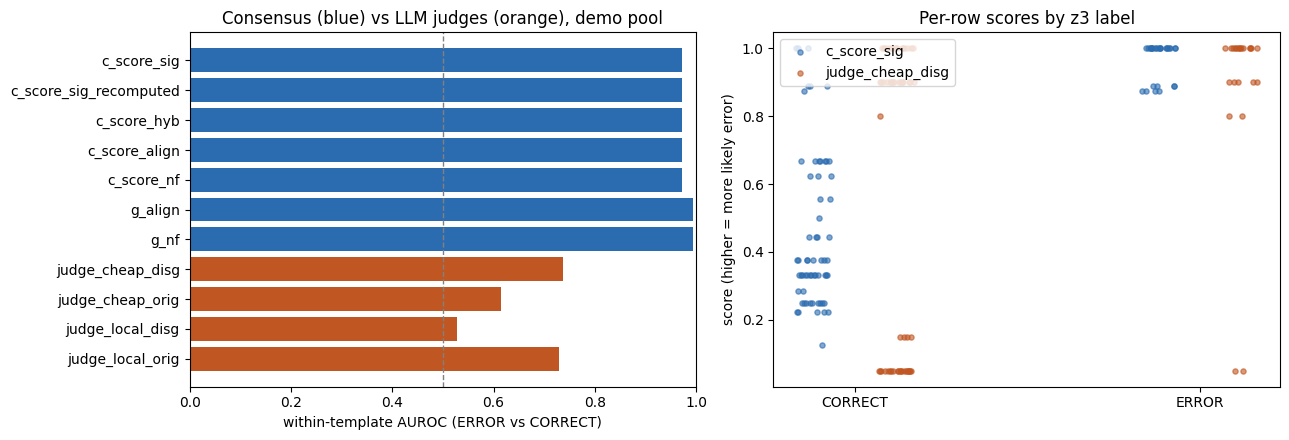

In [14]:
full = data["full_run_primary"]
fmt_ci = lambda c: "[n/a]" if c is None or c[0] is None else f"[{c[0]:+.3f}, {c[1]:+.3f}]"
print(f"{'':<34}{'n':>6}{'err':>5}{'sent':>6}{'AUROC c_sig':>13}{'AUROC judge':>13}{'delta':>9}  {'95% CI':<18}{'PASS':>5}")
for name, p in (("full run (220 sentences, B=2000)", full), (f"demo ({prim['n_sentences']} sentences, B={B})", prim)):
    print(f"{name:<34}{p['n']:>6}{p['n_error']:>5}{p['n_sentences']:>6}{p['auroc_metric']:>13.3f}{p['auroc_comparator']:>13.3f}"
          f"{p['delta']:>+9.3f}  {fmt_ci(p['ci']):<18}{str(p['PASS']):>5}")

# within-template AUROC of every stored score on the demo pool (point estimates, same StratAUC code)
METRICS = ["c_score_sig", "c_score_sig_recomputed", "c_score_hyb", "c_score_align", "c_score_nf", "g_align", "g_nf",
           "judge_cheap_disg", "judge_cheap_orig", "judge_local_disg", "judge_local_orig"]
auc = {}
for m in METRICS:
    rr = [r for r in pool if r.get(m) is not None]
    auc[m] = auc_obj(ctx, rr, m, "template").value() if rr else float("nan")
print()
full_tab = data.get("full_run_auroc_table") or {}
print(f"{'metric':<26}{'demo AUROC':>11}{'full AUROC':>11}")
for m in METRICS:
    fa = (full_tab.get(m) or {}).get("template", {}).get("auroc")
    print(f"{m:<26}{auc[m]:>11.3f}{('' if fa is None else f'{fa:.3f}'):>11}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cols = ["#2b6cb0" if m.startswith(("c_", "g_")) else "#c05621" for m in METRICS]
axes[0].barh(METRICS[::-1], [auc[m] for m in METRICS][::-1], color=cols[::-1])
axes[0].axvline(0.5, color="grey", ls="--", lw=1)
axes[0].set_xlim(0, 1)
axes[0].set_xlabel("within-template AUROC (ERROR vs CORRECT)")
axes[0].set_title("Consensus (blue) vs LLM judges (orange), demo pool")

for m, c, off in (("c_score_sig", "#2b6cb0", -0.12), ("judge_cheap_disg", "#c05621", 0.12)):
    for j, lab in enumerate(["CORRECT", "ERROR"]):
        v = [r[m] for r in pool if r["label"] == lab and r.get(m) is not None]
        x = j + off + np.random.default_rng(j).uniform(-0.05, 0.05, len(v))
        axes[1].scatter(x, v, s=14, alpha=0.6, color=c, label=m if j == 0 else None)
axes[1].set_xticks([0, 1], ["CORRECT", "ERROR"])
axes[1].set_ylabel("score (higher = more likely error)")
axes[1].set_title("Per-row scores by z3 label")
axes[1].legend(loc="upper left")
plt.tight_layout()
plt.show()